In [1]:
# =======================================
# Exercise 1: Load the Dataset
# =======================================

# Import the required liberaries
import pandas as pd
import numpy as np

# Load the Dataset
df=pd.read_csv("diabetes.csv")

# Display the first five row
print(df.head(5))
# or simply 
# df.head()

# Display the last five rows
print(df.tail())

# Display dataset shape
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766    

In [2]:
# =======================================
# Exercise 2: Explore the Dataset
# =======================================
df.info()
print("=" * 50)
# 1. How many rows are there?
print(df.shape[0])
print("=" * 50)

# 2. How many columns?
print(df.shape[1])
print("=" * 50)

# 3. What are the feature names?
col_list=[]
for col in df.columns:
    col_list.append(col)
for feature in col_list[0:8]:
    print(feature)
print("=" * 50)
features=col_list[0:8]
print(features)
print("=" * 50)
# 4. Which column is the target variable?
print(col_list[8])
print("=" * 50)

# 5. What are the data types?
print(df.dtypes)
print("=" * 50)

# 6. Are there missing values?
df_missing=df.isnull().sum()
print(df_missing)
print("=" * 50)

# 7. Display statistical summary.
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
768
9
Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Outcome
Pregnancies            

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [3]:
# =======================================
# Exercise 3: Data Cleaning
# =======================================

# ==========================================
# Check Duplicate Rows
# ==========================================
duplicates = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)
# df = df.drop_duplicates()
print("="*50)
# ==========================================
# Check Zero columns
# ==========================================
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
print("Number of Zero Values\n")
for column in zero_columns:
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")
print("="*50)
# ==========================================
# Replace all impossible zero values with NaN.
# ==========================================
df[zero_columns] = df[zero_columns].replace(0, np.nan)
print(df[zero_columns])
print("="*50)
# ==========================================
# Replace missing values using the median of each column.
# ==========================================
df[zero_columns]=df[zero_columns].fillna(df[zero_columns].median())

Number of Duplicate Rows: 0
Number of Zero Values

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
     Glucose  BloodPressure  SkinThickness  Insulin   BMI
0      148.0           72.0           35.0      NaN  33.6
1       85.0           66.0           29.0      NaN  26.6
2      183.0           64.0            NaN      NaN  23.3
3       89.0           66.0           23.0     94.0  28.1
4      137.0           40.0           35.0    168.0  43.1
..       ...            ...            ...      ...   ...
763    101.0           76.0           48.0    180.0  32.9
764    122.0           70.0           27.0      NaN  36.8
765    121.0           72.0           23.0    112.0  26.2
766    126.0           60.0            NaN      NaN  30.1
767     93.0           70.0           31.0      NaN  30.4

[768 rows x 5 columns]


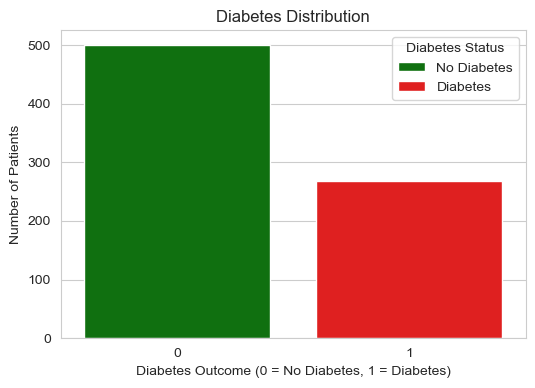

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
The dataset is imbalanced because there are more non-diabetic(500) patients than diabetic(268) patients.


In [4]:
# =======================================
# Exercise 4: Exploratory Data Analysis (EDA)
# =======================================

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Set visualization style

sns.set_style("whitegrid")
# ==========================================
# Chart 1: Diabetes Distribution
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome",data=df,hue="Outcome",palette={0: "green", 1: "red"})
plt.title("Diabetes Distribution")
plt.xlabel("Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
# Change legend labels
plt.legend(title="Diabetes Status",labels=["No Diabetes", "Diabetes"])
plt.show()

print(df.shape)
print(df["Outcome"].value_counts())
print("The dataset is imbalanced because there are more non-diabetic(500) patients than diabetic(268) patients.")

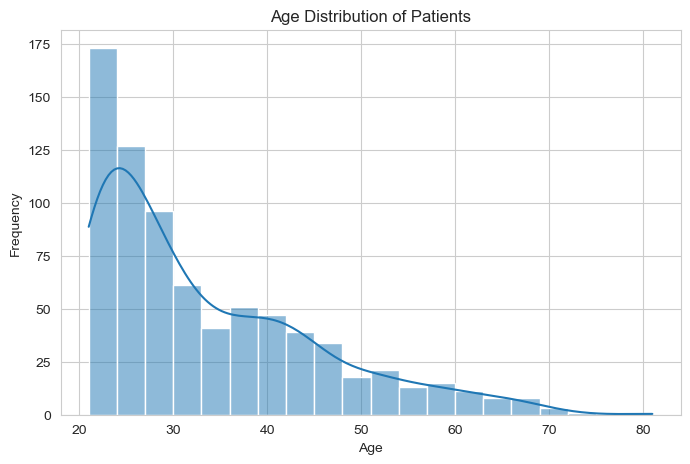

The most frequent age group is approximately 20–30 years old.
Right-skewed distribution (positively skewed distribution).


In [5]:
# ==========================================
# Chart 2: Age Distribution
# ==========================================
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],bins=20,kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("The most frequent age group is approximately 20–30 years old.")
# The distribution is not symmetric.
#         A high concentration of patients at younger ages (around 20–35 years).
#         A long tail extending toward older ages (50–80 years).
#         The left side rises quickly, but the right side decreases slowly.
print("Right-skewed distribution (positively skewed distribution).")

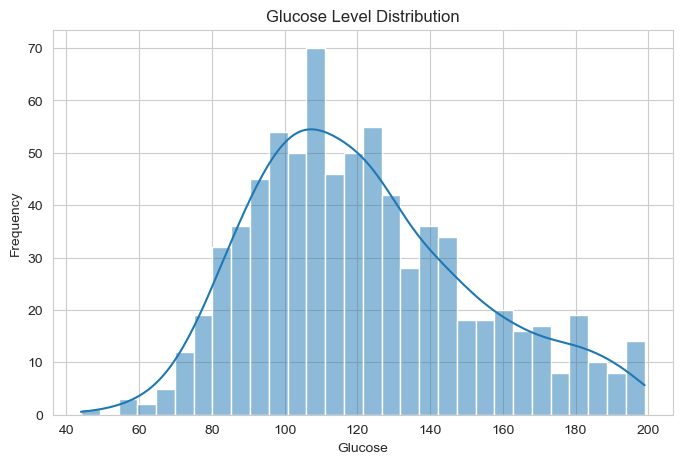

Lower Bound: 39.0
Upper Bound: 201.0

Number of Glucose Outliers: 0

Outlier Values:
Series([], Name: Glucose, dtype: float64)
Mean: 121.65625
Median: 117.0


In [6]:
# ==========================================
# Chart 3: Glucose Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df["Glucose"],bins=30,kde=True)
plt.title("Glucose Level Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()
print("="*90)

# ==========================================
# Detect Glucose Outliers Using IQR
# ==========================================

Q1 = df["Glucose"].quantile(0.25)
Q3 = df["Glucose"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Select outliers
glucose_outliers = df[
    (df["Glucose"] < lower_bound) |
    (df["Glucose"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Glucose Outliers:", len(glucose_outliers))

print("\nOutlier Values:")
print(glucose_outliers["Glucose"])
print("="*90)
# To check the distribution is normal or not
print("Mean:", df["Glucose"].mean())
print("Median:", df["Glucose"].median())
# The glucose values are not perfectly normally distributed. The histogram shows a
# slightly right-skewed distribution, where most glucose values are concentrated 
# around the middle range (100–120), but some patients have higher glucose levels
# that extend the right tail. Therefore, the data is approximately normal but has
# some deviation from a perfect bell-shaped distribution

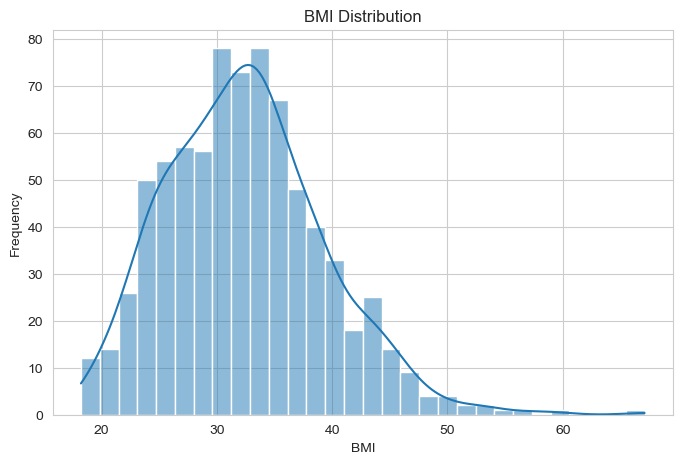

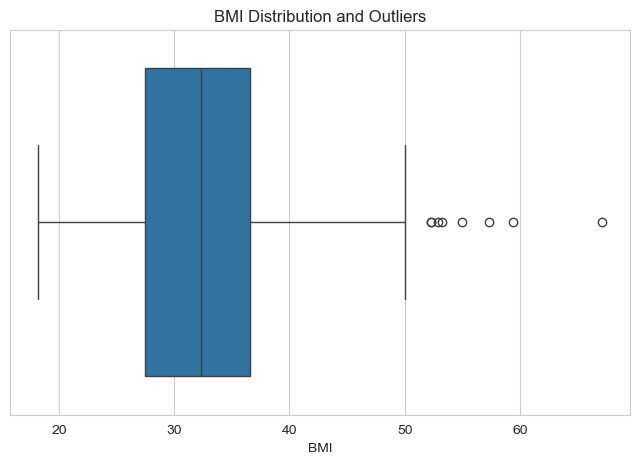

In [7]:
# ==========================================
# Chart 4: BMI Distribution
# ==========================================
plt.figure(figsize=(8,5))
sns.histplot(df["BMI"],bins=30,kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()
print("="*90)


# there is some extreme value
plt.figure(figsize=(8,5))
sns.boxplot(x=df["BMI"])
plt.title("BMI Distribution and Outliers")
plt.xlabel("BMI")
plt.show()

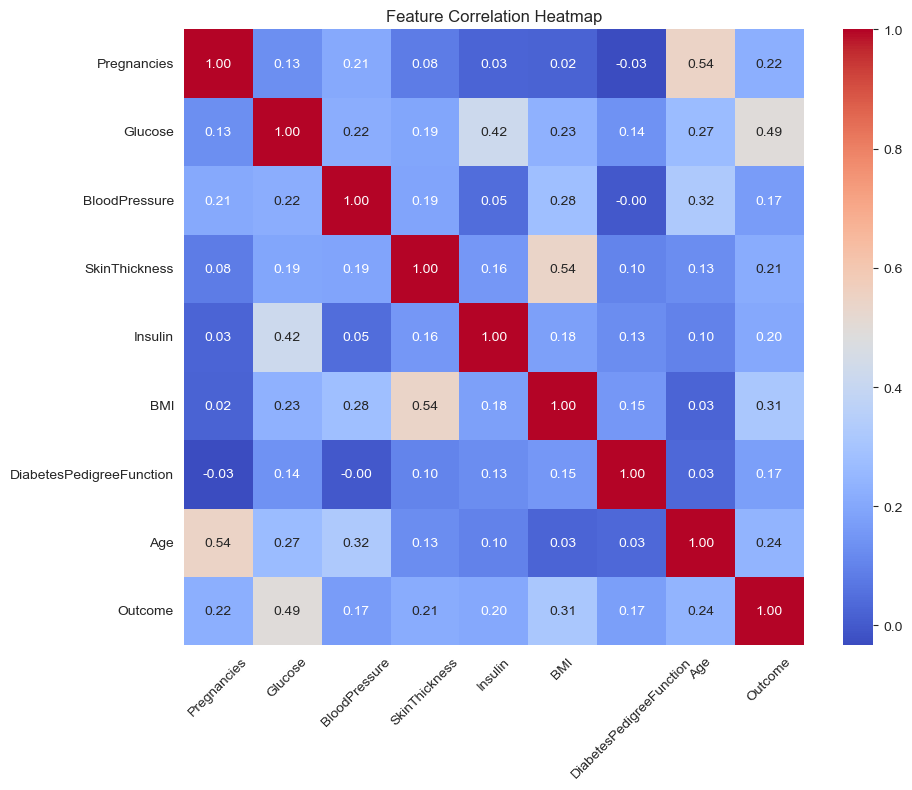

In [8]:
# ==========================================
# Chart 5: Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

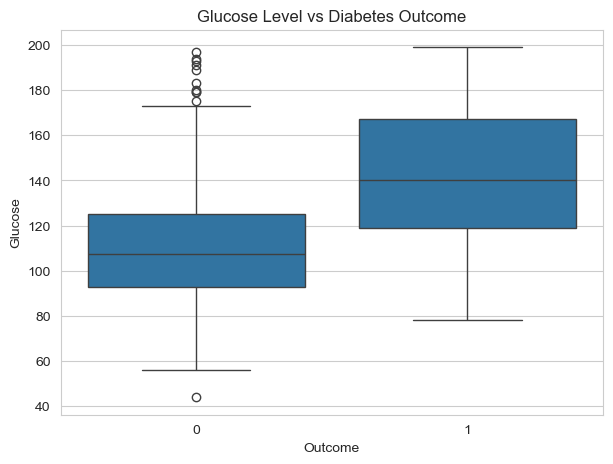

In [9]:
# ==========================================
# Chart 6: Boxplot
# Glucose vs Outcome
# ==========================================

plt.figure(figsize=(7,5))
sns.boxplot(x="Outcome",y="Glucose",data=df)
plt.title("Glucose Level vs Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.show()

In [10]:
# =======================================
# Exercise 5: Prepare the Data
# =======================================

# Features
X = df.drop("Outcome", axis=1)
# Target
y = df["Outcome"]
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (768, 8)
Target Shape: (768,)


In [11]:
# =======================================
# Exercise 6: Train-Test Split
# =======================================

# Import the required liberaries
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,              # Features
    y,              # Target
    test_size=0.20, # 20% testing data
    random_state=42 # Reproducible result
)

# check data size
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (614, 8)
Testing Features: (154, 8)
Training Target: (614,)
Testing Target: (154,)


In [12]:
# =======================================
# Exercise 7: Feature Scaling
# =======================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Training data
X_train_scaled = scaler.fit_transform(X_train)

# Testing data
X_test_scaled = scaler.transform(X_test)


print("Training data after scaling:")
print(X_train_scaled[:5])


print("\nTesting data after scaling:")
print(X_test_scaled[:5])
# Question 1:
# Why is feature scaling important?
# Answer:Feature scaling is important because machine learning algorithms use mathematical 
# calculations based on feature values. Features with larger numerical ranges can dominate 
# smaller features.Scaling puts all features into the same range, improvingmodel performance.

# Question 2:
# Why do we use fit_transform() only on training data?
# Answer:fit_transform() learns the statistical information (mean and standard deviation)
# from the training data. If we apply it to test data, the model will indirectly see 
# information from the test set, causing data leakage.

# Question 3:
# Why do we use transform() on testing data?
# Answer:We use transform() because the testing data must use the same scaling parameters
# learned from the training data. This simulates real-world prediction where new patient
# data is scaled using the existing model settings.


Training data after scaling:
[[-0.52639686 -1.25688146 -0.01899526  0.03429766 -0.17561958 -0.00745016
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.32605067  0.8081742  -0.56058261 -0.17561958 -0.59909194
   2.41502991  1.48710085]
 [-0.82846011  0.57153617 -2.16963585 -1.15546287 -0.65219306 -0.52694051
   0.54916055 -0.94893896]
 [-1.13052335  1.30290323 -1.83876807  0.03429766 -0.17561958 -1.50820005
  -0.63929127  2.79212217]
 [ 0.68185612  0.40531639  0.64274031  0.98610608  2.60439237  1.99835977
  -0.68682934  1.13909516]]

Testing data after scaling:
[[ 0.68185612 -0.79146606 -1.1770325   0.51020187  0.56193461  0.23786472
  -0.11637247  0.87809089]
 [-0.52639686 -0.32605067  0.22915558  0.39122582 -0.17561958  0.4831796
  -0.954231   -1.03594038]
 [-0.52639686 -0.45902649 -0.68073083  0.03429766 -0.17561958 -0.22390447
  -0.9245197  -1.03594038]
 [ 1.28598261 -0.49227045  0.64274031  0.03429766 -0.17561958 -1.11858229
   1.14932872  0.0950781 ]
 [ 0.98391937  0.4718043   1.4699

In [17]:
# =======================================
# Exercise 8: Train Multiple Models
# =======================================

# Step 1: Import Required Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression Model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

# Support Vector Machine
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

print("All models trained successfully!")

All models trained successfully!


In [25]:
# =======================================
# Exercise 9: Model Evaluation
# =======================================

# Step 1: Import Required Libraries
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =======================================
# Model Evaluation Function
# =======================================

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }


# =======================================
# Evaluate All Models
# =======================================

log_results = evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred
)

dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

svm_results = evaluate_model(
    "Support Vector Machine",
    y_test,
    svm_pred
)

knn_results = evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_pred
)

# =======================================
# Model Comparison Table
# =======================================

results_df = pd.DataFrame([
    log_results,
    dt_results,
    rf_results,
    svm_results,
    knn_results
])

print("\n")
print("=" * 60)
print("Model Performance Comparison")
print("=" * 60)

print(results_df)

# =======================================
# Best Model
# =======================================

best_model = results_df.loc[
    results_df["Recall"].idxmax()
]

print("\n")
print("=" * 60)
print("Best Performing Model")
print("=" * 60)

print(best_model)

Model: Logistic Regression
Accuracy : 0.7532
Precision: 0.6667
Recall   : 0.6182
F1 Score : 0.6415

Confusion Matrix
[[82 17]
 [21 34]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Model: Decision Tree
Accuracy : 0.7208
Precision: 0.6034
Recall   : 0.6364
F1 Score : 0.6195

Confusion Matrix
[[76 23]
 [20 35]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154

Model: Random Forest
Accuracy : 0.

In [21]:
# =======================================
# Exercise 10: Choose the Best Model
# =======================================

# 1. Which model achieved the highest Accuracy?
# Answer:The Logistic Regression model achieved the highest Accuracy.
# Accuracy: 0.7532 (75.32%)
# This means Logistic Regression correctly classified approximately 75% of the test samples.

# 2. Which model achieved the highest Recall?
# Answer:The Random Forest model achieved the highest Recall.
# Recall: 0.6727 (67.27%)
# A higher Recall means the model correctly identified more patients who actually have 
# diabetes, reducing the number of false negatives.

# 3. Which model achieved the highest F1 Score?
# Answer:The Random Forest model achieved the highest F1 Score.
# F1 Score: 0.6549 (65.49%)
# The F1 Score combines Precision and Recall into a single metric, making it useful when
# both false positives and false negatives are important.

# 4. Which model would you recommend? Explain your answer.
# Answer:I would recommend the Random Forest Classifier.

# Reasons:
# It achieved the highest Recall (67.27%), meaning it correctly identified more patients
# with diabetes.It achieved the highest F1 Score (65.49%), indicating the best balance 
# between Precision and Recall.Although Logistic Regression achieved a slightly higher 
# Accuracy (75.32%), the difference is very small(75.32% vs. 74.68%).In medical diagnosis,
# Recall is more important than Accuracy because failing to detect a patient who has 
# diabetes (a false negative)can lead to delayed treatment and serious health complications.
# Therefore, Random Forest provides a better overall balance and is more reliable for predicting diabetes.

In [26]:
# =======================================
# Exercise 11: Save the Best Model
# =======================================

# Step 1: Import Required Libraries

import os
import joblib
import json

# =======================================
# Step 2: Create Models Folder
# =======================================

if not os.path.exists("models"):
    os.makedirs("models")

# =======================================
# Step 3: Select Best Model
# =======================================

# Random Forest was selected as the best model
best_model = rf_model

# =======================================
# Step 4: Save Best Model Using Joblib
# =======================================

model_path = "models/best_model.pkl"
joblib.dump(best_model, model_path)
print("Best model saved successfully!")
print("Location:", model_path)

# =======================================
# Step 5: Save Feature Names
# =======================================

feature_info = {
    "features": list(X.columns)
}


feature_path = "models/feature_info.json"


with open(feature_path, "w") as file:
    json.dump(feature_info, file, indent=4)


print("Feature information saved successfully!")
print("Location:", feature_path)



# =======================================
# Step 6: Verify Saved Files
# =======================================

print("\nSaved Files:")

print(os.listdir("models"))



Best model saved successfully!
Location: models/best_model.pkl
Feature information saved successfully!
Location: models/feature_info.json

Saved Files:
['best_model.pkl', 'feature_info.json']


In [ ]:
# =======================================
# Exercise 12: Interpretation Questions
# =======================================

# Question 1: What is Classification?
# Answer:Classification is a supervised machine learning technique
# used to predict a category or class label from input data.

# The model learns patterns from historical labeled data and uses
# those patterns to classify new observations.

# Question 2: Why is this a binary classification problem?
# Answer:This is a binary classification problem because the target 
# variable has only two possible classes.


# Question 3: Explain Accuracy, Precision, Recall, and F1 Score
# 1. Accuracy:
# Accuracy measures the percentage of total predictions that are correct.
# 2. Precision:
# Precision tells us:Among patients predicted as diabetic, how many actually have diabetes?
# 3. Recall:
# Recall tells us:Among all actual diabetic patients, how many did the model correctly identify?
# 4. F1 Score
# F1 Score combines precision and recall into one measurement

# Question 4: What is a False Positive?
# A False Positive (FP) occurs when the model predicts a positive result, but the actual result is negative.

# Question 5: What is a False Negative?
# A False Negative (FN) occurs when the model predicts a negative result, but the actual result is positive.

# Question 6: Which error is more dangerous in diabetes prediction? Why?
    # For diabetes prediction, False Negative errors are more dangerous because they fail to 
    # identify patients who need medical attention. Therefore, healthcare prediction systems
    # often aim to reduce False Negatives by improving Recall (Sensitivity).

# Question 7: Why should we save the trained model?
    # We save the trained model because:
        # Training requires time and computational resources.
        # We can reuse the model for future predictions.
        # It allows deployment in real applications.
        # It ensures consistent predictions.
# Question 8: Why should we save the feature metadata?
    # Feature metadata stores the input feature information used during training.
        # It helps because:
            # The model expects the same feature order.
            # It prevents incorrect input during prediction.
            # It makes deployment easier.
            # It improves reproducibility.
